In [3]:
# Notebook 02: PCA Analysis
#
# Purpose:
# - Load merged county-level modeling data
# - Select PCA variables
# - Align feature direction for risk
# - Handle missing values
# - Standardize variables
# - Run PCA
# - Create county-level composite risk scores

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [5]:
BASE_DIR = Path.cwd().parent
model_file = BASE_DIR / "data" / "merged" / "gc_cpri_model_input.csv"

df = pd.read_csv(model_file)
df.head()

,county,registered_voters,total_ballots_cast,turnout_rate,absentee_rate,population_2023,poverty_rate,pct_less_hs,pct_bachelors,unemployment_rate,median_income,non_white_share,rural_urban_code,broadband_access_rate
0,BALDWIN,207643,122542,0.5902,0.0634,243176.00,10.0,8.268600,32.797637,3.400,71704.0,0.082985,3.0,0.870
1,CLARKE,19143,11993,0.6265,0.0604,22659.50,19.0,14.731304,15.426531,6.350,44906.0,0.413350,9.0,0.666
2,CONECUH,9820,6105,0.6217,0.0785,11318.00,26.5,12.513843,13.129076,4.875,36106.0,0.431829,9.0,0.634
3,ESCAMBIA,28268,15009,0.5310,0.0477,36634.75,21.3,17.467352,12.490686,4.200,47792.0,0.271598,6.0,0.690
4,MOBILE,322535,176019,0.5457,0.0489,412699.50,16.3,10.991693,25.150224,4.850,54315.0,0.355915,2.0,0.800


In [6]:
candidate_features = [
    "poverty_rate",
    "unemployment_rate",
    "median_income",
    "pct_less_hs",
    "non_white_share",
    "rural_urban_code",
    "broadband_access_rate"
]

pca_df = df[candidate_features].copy()
pca_df.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
0,10.0,3.400,71704.0,8.268600,0.082985,3.0,0.870
1,19.0,6.350,44906.0,14.731304,0.413350,9.0,0.666
2,26.5,4.875,36106.0,12.513843,0.431829,9.0,0.634
3,21.3,4.200,47792.0,17.467352,0.271598,6.0,0.690
4,16.3,4.850,54315.0,10.991693,0.355915,2.0,0.800


In [7]:
pca_df.describe()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
count,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,18.70000,4.885714,50872.285714,13.096151,0.314081,6.428571,0.703714
std,4.98832,0.949326,11021.269054,3.262040,0.122100,2.878492,0.103797
min,10.00000,3.400000,36106.000000,8.268600,0.082985,2.000000,0.558000
25%,17.50000,4.525000,46202.000000,11.153325,0.263614,4.500000,0.650000
50%,19.00000,4.875000,47792.000000,12.513843,0.355915,8.000000,0.690000
75%,20.20000,5.262500,54050.000000,15.558307,0.400305,8.500000,0.754000
max,26.50000,6.350000,71704.000000,17.467352,0.431829,9.000000,0.870000


In [8]:
# poverty: higher poverty = higher risk
if pca_df["poverty_rate"].max() > 1:
    pca_df["poverty_rate"] = pca_df["poverty_rate"] / 100

# unemployment: higher unemployment = higher risk
if pca_df["unemployment_rate"].max() > 1:
    pca_df["unemployment_rate"] = pca_df["unemployment_rate"] / 100

# education: higher % less than HS = higher risk
if pca_df["pct_less_hs"].max() > 1:
    pca_df["pct_less_hs"] = pca_df["pct_less_hs"] / 100

# income: higher income = lower risk
pca_df["median_income"] = -1 * pca_df["median_income"]

# rural: higher = more rural = higher risk
pca_df["rural_urban_code"] = pca_df["rural_urban_code"]

# broadband: higher = less access = higher risk
pca_df["broadband_access_rate"] = 1 - pca_df["broadband_access_rate"]

pca_df.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
0,0.100,0.03400,-71704.0,0.082686,0.082985,3.0,0.130
1,0.190,0.06350,-44906.0,0.147313,0.413350,9.0,0.334
2,0.265,0.04875,-36106.0,0.125138,0.431829,9.0,0.366
3,0.213,0.04200,-47792.0,0.174674,0.271598,6.0,0.310
4,0.163,0.04850,-54315.0,0.109917,0.355915,2.0,0.200


In [9]:
pca_df.isna().sum()

poverty_rate             0
unemployment_rate        0
median_income            0
pct_less_hs              0
non_white_share          0
rural_urban_code         0
broadband_access_rate    0
dtype: int64

In [10]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(pca_df),
    columns=pca_df.columns
)

X_imputed.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
0,0.100,0.03400,-71704.0,0.082686,0.082985,3.0,0.130
1,0.190,0.06350,-44906.0,0.147313,0.413350,9.0,0.334
2,0.265,0.04875,-36106.0,0.125138,0.431829,9.0,0.366
3,0.213,0.04200,-47792.0,0.174674,0.271598,6.0,0.310
4,0.163,0.04850,-54315.0,0.109917,0.355915,2.0,0.200


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [12]:
corr = X_imputed.corr()
corr

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code,broadband_access_rate
poverty_rate,1.000000,0.418467,0.957432,0.570299,0.759941,0.705721,0.748974
unemployment_rate,0.418467,1.000000,0.639553,0.494264,0.821927,0.638449,0.688364
median_income,0.957432,0.639553,1.000000,0.643081,0.902553,0.732275,0.815333
pct_less_hs,0.570299,0.494264,0.643081,1.000000,0.535804,0.516076,0.774441
non_white_share,0.759941,0.821927,0.902553,0.535804,1.000000,0.572112,0.745424
rural_urban_code,0.705721,0.638449,0.732275,0.516076,0.572112,1.000000,0.830680
broadband_access_rate,0.748974,0.688364,0.815333,0.774441,0.745424,0.830680,1.000000


In [13]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [14]:
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,7.399186e-01,0.739919
1,PC2,9.477196e-02,0.834691
2,PC3,8.376146e-02,0.918452
3,PC4,6.681259e-02,0.985265
4,PC5,1.376464e-02,0.999029
5,PC6,9.707385e-04,1.000000
6,PC7,4.158945e-35,1.000000


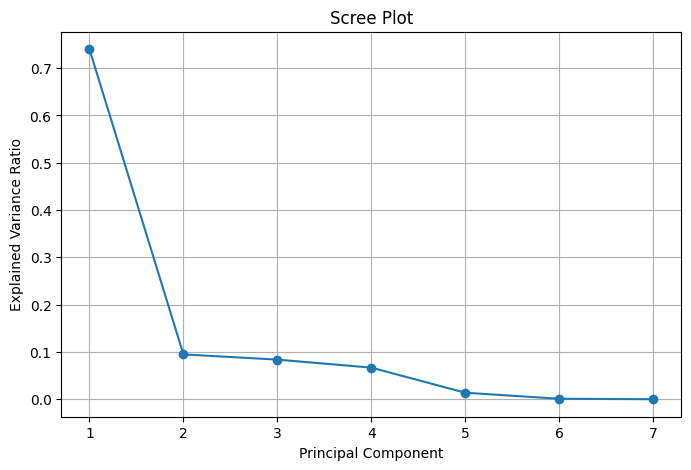

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

In [16]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_imputed.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
poverty_rate,0.381282,-0.465810,-0.409679,-0.035224,-0.121862,0.627150,-0.245766
unemployment_rate,0.341447,0.758420,0.108439,0.017804,-0.252680,0.448054,0.177589
median_income,0.418692,-0.164395,-0.319245,-0.149025,-0.180737,-0.345729,0.722047
pct_less_hs,0.328123,-0.268948,0.713137,-0.429720,-0.318677,-0.074433,-0.140296
non_white_share,0.392048,0.317065,-0.340323,-0.370373,0.203580,-0.413805,-0.529238
rural_urban_code,0.365495,-0.051467,0.086901,0.792612,-0.278191,-0.306482,-0.238029
broadband_access_rate,0.409612,-0.072680,0.294197,0.161753,0.817463,0.125285,0.174001


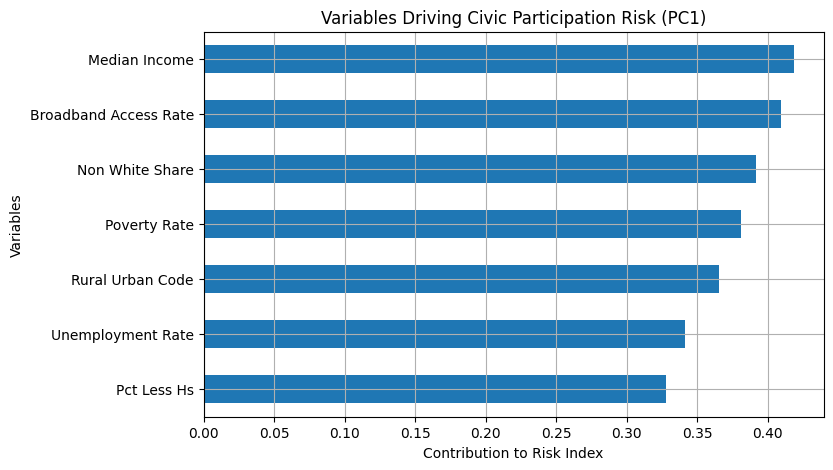

In [17]:
# PC1 Loadings Bar Chart

plt.figure(figsize=(8, 5))

# Format variable names
formatted_index = (
    loadings["PC1"]
    .sort_values()
    .index
    .str.replace("_", " ")     
    .str.title()              
)

# Plot using formatted labels
loadings["PC1"].sort_values().set_axis(formatted_index).plot(kind="barh")

plt.title("Variables Driving Civic Participation Risk (PC1)")
plt.xlabel("Contribution to Risk Index")
plt.ylabel("Variables")

plt.grid(True)

plt.show()

In [18]:
df["gc_cpri_score_raw"] = X_pca[:, 0]
df[["county", "gc_cpri_score_raw"]].head()

,county,gc_cpri_score_raw
0,BALDWIN,-4.655228
1,CLARKE,1.873802
2,CONECUH,2.240629
3,ESCAMBIA,0.401916
4,MOBILE,-1.454626


In [19]:
df["gc_cpri_score"] = (
    (df["gc_cpri_score_raw"] - df["gc_cpri_score_raw"].min()) /
    (df["gc_cpri_score_raw"].max() - df["gc_cpri_score_raw"].min())
) * 100

df[["county", "gc_cpri_score"]].head()

,county,gc_cpri_score
0,BALDWIN,0.000000
1,CLARKE,94.680471
2,CONECUH,100.000000
3,ESCAMBIA,73.335975
4,MOBILE,46.413402


In [20]:
df[["county", "gc_cpri_score"]].sort_values("gc_cpri_score", ascending=False).head(10)

,county,gc_cpri_score
2,CONECUH,100.000000
5,MONROE,95.294925
1,CLARKE,94.680471
3,ESCAMBIA,73.335975
6,WASHINGTON,62.828481
4,MOBILE,46.413402
0,BALDWIN,0.000000


In [21]:
OUTPUT_DIR = BASE_DIR / "data" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_DIR / "gc_cpri_scored_counties.csv", index=False)
loadings.to_csv(OUTPUT_DIR / "gc_cpri_pca_loadings.csv")
explained_variance.to_csv(OUTPUT_DIR / "gc_cpri_explained_variance.csv", index=False)